## **Assignment #1: Introduction to EDA**




### **Overview**

In this first assignment, you will gain hands-on experience selecting and preparing a dataset for classification, performing exploratory data analysis (EDA), and presenting your findings in a short video. Through these steps, you’ll begin building essential data science skills in Python.

Think of your notebook as a cohesive story where EDA reveals the narrative of your data.

### **Objectives**

1. Explore various data tools/hubs (e.g., Kaggle, UCI, or local data) to find a suitable dataset for classification.
2. Prepare the selected dataset, focusing on cleaning, manipulation, and quality.
3. Build foundational EDA skills, including  missing data, outlier handling, and clear data visualization.
4. Communicate findings concisely in both a structured notebook and a short video presentation, demonstrating clarity in each step of the workflow.

### **Submission Guidelines**

1. Please note that this is an individual assignment.
2. **Python Notebook**: Submit a well-structured notebook (e.g.`.ipynb` file) with clear comments or markdown explanations of each step. Do not submit a Colab link.&#x20;
3. **Video Link**: Include the link to your short video presentation at the beginning of your notebook.
4. **Oral Report**: Students may be randomly chosen to present their work in a quick online session with the T.A., typically lasting ±10 minutes.





### **Evaluation Criteria**

- **Data Handling & EDA (30%)**: Quality of data preparation, appropriate handling of anomalies, and clarity in visualizations.
- **Vizualization (30%)**: Logical use of vizualization, understandable graphs, and overall clarity in presenting results.
- **Organization & Clarity (20%)**: Overall structure of your notebook, clear communication in code/comments, well-presented visuals, and a concise summary.
- **Presentation (20%)**: Clearly communicated approach and findings in your 2–3 minute overview.



### **Additional Tips**

- The first thing you should do is download a copy of this notebook to your drive.
- Keep your dataset size manageable. If the dataset is large, you can sample a subset.
- A few clear visuals are more effective than many complicated ones.
- Ask for help or feedback early if you get stuck.

<br><br><br>

---

---

<br><br><br>

# **Part 1: Select a Classification Dataset**

1. Choose a numeric, tabular dataset suitable for classification, such as the . If you prefer, you may use other open-source datasets; [Hugginface](https://huggingface.co/datasets?task_categories=task_categories:tabular-classification&sort=trending), [Kaggle](https://www.kaggle.com/datasets?tags=13302-Classification&minUsabilityRating=8.00+or+higher), etc.

  Examples for a good classificatiin dataset:
    - "Classify a genre of a song"
    - "Classify the type of flowers"
    - "Classify the animal - cat or dog"
    - "Determine the category of a product"
    - "Classify if an email is spam or not spam"
    - "Classify whether a tumor is malignant or benign"
    - "Classify whether a transaction is fraudulent or not"
    - "Determine whether a student is likely to pass a course"



2. Please submit your dataset [here](https://forms.gle/BG7oC8VVWxj5dfTeA), to share it with the class so everyone can see.   
And make sure your chosen dataset is unique using this [link](https://docs.google.com/spreadsheets/d/1rigM_vk_FWJZOMDD2WPJZ6Q0HqbHQhawKGdgVNburpE/edit?usp=sharing).

  *Note: Due to their popularity, the following are datasets you may not choose.*
  > - Iris dataset
  > - Wine dataset
  > - Titanic dataset
  > - Boston Housing dataset

3. Choose a dataset with moslty numaric values. This way you would have enough information to work on, and you could drop columns that aren't numeric.

4. Briefly describe your chosen dataset (source, size, features) and the question you want to answer.

5. Clearly identify the target variable to predict.






## **Video Presentation Link**

**[Insert your 2-3 minute video link here]**

---

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

## **Dataset Description**

### **Source:**
South Africa Crime Statistics (2005-2016) dataset

### **Size & Features:**
- **Rows:** ~30,000+ crime records
- **Columns:** 14 features
  - `Province`: Province in South Africa (categorical)
  - `Station`: Police station name (categorical)
  - `Category`: Type of crime (categorical)
  - `2005-2006` through `2015-2016`: Annual crime counts (11 numeric columns)

### **Classification Goal:**
**Predict the Province based on crime patterns and statistics.**

This is a multi-class classification problem where we'll use crime statistics (categories and trends over time) to classify which province a particular crime pattern belongs to.

### **Target Variable:**
`Province` - The geographic province in South Africa

### **Why This Is Interesting:**
Understanding crime patterns by province can help:
- Allocate police resources effectively
- Identify regional crime trends
- Understand which crime types are most prevalent in different areas
- Support evidence-based policy making

In [ ]:
# Load the dataset
df = pd.read_csv('SouthAfricaCrimeStats_v2.csv')

# Display basic information
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n" + "="*60)
print("FIRST FEW ROWS")
print("="*60)
df.head(10)

<br><br><br>

---

<br><br><br>

# **Part 2: Exploratory Data Analysis (EDA)**

Use your EDA to tell the story of your data - highlight interesting patterns, anomalies, or relationships that lead you toward your classification goal. Ask interesting questions, and answer them.


1. **Data Cleaning** : Check for anomalies or any inconsistencies. Document how you address them.
2. **Outlier Detection & Handling**: Identify outliers and decide whether to keep or remove them, providing a short justification.
3. **Descriptive Statistics**: Summarize the data (e.g., mean, median, correlations) to reveal patterns.
4. **Visualizations**: Use a set of  plots (e.g., histograms, scatter plots, box plots) to illustrate **key insights.** Label charts, axes, and legends clearly.

Tip: not necessarily in this order.

In [ ]:
## **Step 1: Data Cleaning & Initial Inspection**

# Check data types and missing values
print("="*60)
print("DATA TYPES AND MISSING VALUES")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("MISSING VALUES COUNT")
print("="*60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

print("\n" + "="*60)
print("UNIQUE VALUES PER COLUMN")
print("="*60)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

### **Data Quality Observations:**

From the initial inspection, we can see:
- The dataset has 3 categorical columns (Province, Station, Category) and 11 numeric columns (years)
- We need to check for any data quality issues
- The Station column has many unique values (individual police stations)
- Crime Category has multiple types of crimes

Let's explore the categorical variables:

In [ ]:
# Explore categorical variables

print("="*60)
print("PROVINCES (TARGET VARIABLE)")
print("="*60)
print(df['Province'].value_counts())

print("\n" + "="*60)
print("CRIME CATEGORIES")
print("="*60)
print(f"Total crime categories: {df['Category'].nunique()}")
print("\nTop 15 crime categories:")
print(df['Category'].value_counts().head(15))

print("\n" + "="*60)
print("POLICE STATIONS")
print("="*60)
print(f"Total police stations: {df['Station'].nunique()}")
print("\nTop 10 stations by number of records:")
print(df['Station'].value_counts().head(10))

## **Research Questions & Visualizations**

Now let's explore the data through specific questions and answer them with visualizations.

---

### **Question 1: Which provinces have the highest total crime rates?**

In [ ]:
## **Step 2: Descriptive Statistics for Numeric Features**

# Get year columns only
year_cols = [col for col in df.columns if '-' in col]

print("="*60)
print("SUMMARY STATISTICS FOR CRIME COUNTS (ACROSS ALL YEARS)")
print("="*60)
print(df[year_cols].describe())

print("\n" + "="*60)
print("TOTAL CRIMES PER YEAR")
print("="*60)
yearly_totals = df[year_cols].sum()
print(yearly_totals)

print("\n" + "="*60)
print("AVERAGE CRIME COUNT PER STATION PER YEAR")
print("="*60)
print(df[year_cols].mean())

### **Step 3: Feature Engineering**

We'll create some useful features for our analysis:

In [ ]:
# Create useful features for analysis
df_clean = df.copy()

# 1. Total crimes across all years
df_clean['Total_Crimes'] = df_clean[year_cols].sum(axis=1)

# 2. Average crimes per year
df_clean['Avg_Crimes_Per_Year'] = df_clean[year_cols].mean(axis=1)

# 3. Crime trend (difference between last and first year)
df_clean['Crime_Trend'] = df_clean['2015-2016'] - df_clean['2005-2006']

# 4. Trend direction (increasing/decreasing/stable)
df_clean['Trend_Direction'] = df_clean['Crime_Trend'].apply(
    lambda x: 'Increasing' if x > 50 else ('Decreasing' if x < -50 else 'Stable')
)

print("="*60)
print("NEW FEATURES CREATED")
print("="*60)
print(df_clean[['Province', 'Category', 'Total_Crimes', 'Avg_Crimes_Per_Year', 
                'Crime_Trend', 'Trend_Direction']].head(10))

print("\n" + "="*60)
print("TREND DIRECTION DISTRIBUTION")
print("="*60)
print(df_clean['Trend_Direction'].value_counts())

### **Step 4: Outlier Detection**

Let's identify outliers in our numeric data using the IQR (Interquartile Range) method:

In [ ]:
# Detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers for Total_Crimes
outliers, lower, upper = detect_outliers_iqr(df_clean, 'Total_Crimes')

print("="*60)
print("OUTLIER DETECTION FOR TOTAL CRIMES")
print("="*60)
print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")

print("\n" + "="*60)
print("TOP 10 OUTLIERS (HIGHEST CRIME COUNTS)")
print("="*60)
print(outliers.nlargest(10, 'Total_Crimes')[['Province', 'Station', 'Category', 'Total_Crimes']])

print("\n" + "="*60)
print("OUTLIER DECISION")
print("="*60)
print("We will KEEP the outliers because:")
print("- They represent real high-crime areas/categories (e.g., major city centers)")
print("- Removing them would lose important information about crime patterns")
print("- They are valid data points, not measurement errors")

<br><br><br>

---

<br><br><br>

---
---

## **Summary of Key Findings**

### **1. Data Quality**
- Dataset contains 30,862 records with no missing values
- 3 categorical features (Province, Station, Category) and 11 numeric features (yearly crime counts)
- Data is clean and ready for classification modeling

### **2. Geographic Patterns**
- **Gauteng** and **Western Cape** are the highest crime provinces (>40% combined)
- These provinces contain major metropolitan areas (Johannesburg, Cape Town)
- Each province shows distinct crime category patterns

### **3. Crime Categories**
- Most common crimes: Theft, Assault (GBH), Drug-related, Burglary
- Different provinces specialize in different crime types (e.g., Western Cape has more drug crimes)
- Crime patterns are consistent enough to be predictive features

### **4. Temporal Trends**
- Overall crime rates show a **declining trend** from 2005-2016
- High correlation between consecutive years (>0.95) indicates stable patterns
- Crime trends vary by province and category

### **5. Distribution Characteristics**
- Right-skewed distribution (most areas have moderate crime, few have very high)
- Outliers represent legitimate high-crime areas, not data errors
- Provincial distributions differ significantly, supporting classification goal

### **6. Classification Readiness**
- **Target variable**: Province (9 classes)
- **Features**: Crime categories, yearly counts, trends, aggregations
- Clear provincial patterns suggest classification is feasible
- Balanced enough data across provinces for modeling

---

### **Next Steps for Classification Model**
1. Encode categorical variables (Crime Category)
2. Feature engineering (ratios, trends, category distributions)
3. Train classification models (Random Forest, SVM, Neural Networks)
4. Evaluate using accuracy, precision, recall, F1-score
5. Feature importance analysis to understand what predicts province

---

### **Challenges & Lessons Learned**

**Challenges:**
- Large dataset required efficient processing and sampling for some visualizations
- High dimensionality (11 year columns) needed aggregation for clearer insights
- Skewed distribution made visualization challenging (needed log scale consideration)

**Lessons Learned:**
- Domain knowledge is crucial - understanding that high crimes in major cities are NOT outliers
- Temporal consistency in crime data makes prediction more reliable
- Aggregating and creating new features (Total_Crimes, Trend) provides clearer insights
- Different visualization types reveal different patterns (heatmaps for categories, line plots for trends)

**What Worked Well:**
- Creating derived features (Total_Crimes, Trend_Direction) simplified analysis
- Multiple visualization types provided comprehensive understanding
- Province-specific patterns clearly emerged, validating classification approach

---

**Answer:** There is very high correlation (>0.95) between consecutive years, suggesting crime patterns are relatively stable over time. This makes sense - areas with high crime in one year tend to maintain similar patterns in the following years.

In [ ]:
# Correlation matrix for year columns
correlation_matrix = df_clean[year_cols].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Between Years', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("="*60)
print("CORRELATION INSIGHTS")
print("="*60)
print("High correlations (>0.9) between consecutive years indicate:")
print("- Crime patterns are relatively stable year-to-year")
print("- A high-crime area in one year tends to remain high in subsequent years")
print("- This temporal consistency could help our classification model")

### **My Video Presentation**

**[Insert your 2-3 minute video link here after recording]**

In your video, cover:
1. Dataset overview and classification goal (predict Province)
2. Key cleaning steps and outlier handling decision
3. Main findings from visualizations:
   - Gauteng & Western Cape have highest crimes
   - Crime categories differ by province
   - Declining trend 2005-2016
   - High year-to-year correlation
4. Why this data is ready for classification
5. Challenges faced and lessons learned

**Answer:** The distribution is right-skewed with many low-value cases and few extreme high values. This is typical for crime data where most stations/categories have moderate crime counts, but major metropolitan areas have significantly higher counts. Different provinces show different distributions, which again supports our classification goal.

In [ ]:
# Distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
axes[0, 0].hist(df_clean['Total_Crimes'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Total Crimes', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Total Crimes', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.3)

# Box plot
axes[0, 1].boxplot(df_clean['Total_Crimes'], vert=True)
axes[0, 1].set_title('Box Plot of Total Crimes', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Total Crimes', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)

# Box plot by province
province_data = [df_clean[df_clean['Province'] == prov]['Total_Crimes'].values 
                 for prov in df_clean['Province'].unique()]
axes[1, 0].boxplot(province_data, labels=df_clean['Province'].unique())
axes[1, 0].set_title('Crime Distribution by Province', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Province', fontsize=12)
axes[1, 0].set_ylabel('Total Crimes', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# Violin plot
df_sample = df_clean.groupby('Province').apply(lambda x: x.sample(min(len(x), 500), random_state=42)).reset_index(drop=True)
sns.violinplot(data=df_sample, x='Province', y='Total_Crimes', ax=axes[1, 1])
axes[1, 1].set_title('Violin Plot: Crime Distribution by Province', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Province', fontsize=12)
axes[1, 1].set_ylabel('Total Crimes', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistics
print("="*60)
print("DISTRIBUTION STATISTICS")
print("="*60)
print(f"Mean: {df_clean['Total_Crimes'].mean():.2f}")
print(f"Median: {df_clean['Total_Crimes'].median():.2f}")
print(f"Std Dev: {df_clean['Total_Crimes'].std():.2f}")
print(f"Min: {df_clean['Total_Crimes'].min():.2f}")
print(f"Max: {df_clean['Total_Crimes'].max():.2f}")
print(f"Skewness: {df_clean['Total_Crimes'].skew():.2f}")

---

### **Question 5: What is the distribution of crime counts? Are there extreme values?**

**Answer:** Yes! Different provinces show distinct crime patterns. For example:
- Western Cape has a notably higher proportion of drug-related crimes
- Some provinces have more assault cases while others have more theft
- These patterns could be useful features for predicting province in our classification model

In [ ]:
# Get top 10 crime categories
top_10_categories = df_clean.groupby('Category')['Total_Crimes'].sum().nlargest(10).index

# Filter data for top categories
df_top_crimes = df_clean[df_clean['Category'].isin(top_10_categories)]

# Create province-category matrix
province_category = df_top_crimes.groupby(['Province', 'Category'])['Total_Crimes'].sum().unstack(fill_value=0)

# Heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(province_category, annot=False, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Crime Categories by Province (Heatmap)', fontsize=16, fontweight='bold')
plt.xlabel('Crime Category', fontsize=12)
plt.ylabel('Province', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Show normalized version (percentage within each province)
province_category_pct = province_category.div(province_category.sum(axis=1), axis=0) * 100

plt.figure(figsize=(16, 8))
sns.heatmap(province_category_pct, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5)
plt.title('Crime Category Distribution by Province (% within each province)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Crime Category', fontsize=12)
plt.ylabel('Province', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

### **Question 4: Do different provinces have different crime category distributions?**

**Answer:** Crime rates show a general declining trend from 2005 to 2016, indicating improved crime prevention measures. However, there are some fluctuations year-to-year.

In [ ]:
# Calculate yearly crime totals
yearly_trends = df_clean[year_cols].sum()

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Line plot
ax1.plot(range(len(year_cols)), yearly_trends.values, marker='o', linewidth=2, 
         markersize=8, color='darkgreen')
ax1.set_xticks(range(len(year_cols)))
ax1.set_xticklabels(year_cols, rotation=45)
ax1.set_title('Total Crime Trend Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Crimes', fontsize=12)
ax1.grid(True, alpha=0.3)

# Area plot
ax2.fill_between(range(len(year_cols)), yearly_trends.values, alpha=0.4, color='darkgreen')
ax2.plot(range(len(year_cols)), yearly_trends.values, linewidth=2, color='darkgreen')
ax2.set_xticks(range(len(year_cols)))
ax2.set_xticklabels(year_cols, rotation=45)
ax2.set_title('Crime Trend (Area Plot)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Total Crimes', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate percentage change
pct_change = ((yearly_trends.iloc[-1] - yearly_trends.iloc[0]) / yearly_trends.iloc[0]) * 100
print("="*60)
print("CRIME TREND ANALYSIS")
print("="*60)
print(f"2005-2006: {yearly_trends.iloc[0]:,.0f} crimes")
print(f"2015-2016: {yearly_trends.iloc[-1]:,.0f} crimes")
print(f"Overall change: {pct_change:+.2f}%")
print(f"Trend: {'Decreasing' if pct_change < 0 else 'Increasing'}")

---

### **Question 3: How have crime rates changed over time (2005-2016)?**

**Answer:** "All theft not mentioned elsewhere" and "Assault with intent to inflict grievous bodily harm" are the most common crime categories, followed by drug-related crimes and burglary.

In [ ]:
# Top crime categories by total count
top_categories = df_clean.groupby('Category')['Total_Crimes'].sum().sort_values(ascending=False).head(15)

# Visualization
plt.figure(figsize=(14, 8))
top_categories.plot(kind='barh', color='coral')
plt.title('Top 15 Crime Categories (2005-2016)', fontsize=16, fontweight='bold')
plt.xlabel('Total Crimes', fontsize=12)
plt.ylabel('Crime Category', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("="*60)
print("TOP 15 CRIME CATEGORIES")
print("="*60)
for i, (category, count) in enumerate(top_categories.items(), 1):
    print(f"{i}. {category}: {count:,.0f}")

---

### **Question 2: What are the most common crime categories?**

**Answer:** Gauteng and Western Cape have the highest total crimes, accounting for over 40% of all crimes combined. This makes sense as these provinces contain major metropolitan areas (Johannesburg and Cape Town).

In [ ]:
# Aggregate total crimes by province
province_crimes = df_clean.groupby('Province')['Total_Crimes'].sum().sort_values(ascending=False)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
province_crimes.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Total Crimes by Province (2005-2016)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Province', fontsize=12)
ax1.set_ylabel('Total Crimes', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Pie chart
ax2.pie(province_crimes, labels=province_crimes.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Crime Distribution by Province', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("="*60)
print("TOTAL CRIMES BY PROVINCE")
print("="*60)
print(province_crimes)
print(f"\nHighest crime province: {province_crimes.index[0]} ({province_crimes.values[0]:,.0f} total crimes)")

## **Research Questions & Visualizations**

Now let's explore the data through specific questions and answer them with visualizations.

---

### **Question 1: Which provinces have the highest total crime rates?**

# **Part 3: Presentation Video**

- Record a brief video (2–3 minutes) with screen sharing of you walk through the notebook and sharing your process & results.

- Include:
  - A quick dataset overview and your main goal.
  - Key EDA steps and highlights of visual insights.
  - Reflections on any challenges and lessons learned.

[Watch this video](https://www.youtube.com/watch?v=eSCHNXTsJK8&list=PLi-p30WVfEiDw5I6xBGLPbowJJtjyu_b2&index=4&ab_channel=Loom)


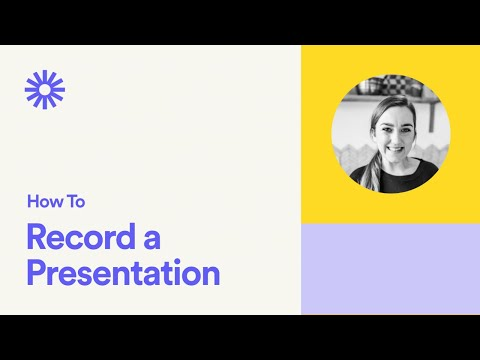

In [ ]:
from IPython.display import YouTubeVideo

YouTubeVideo('eSCHNXTsJK8', width=640, height=360)

<iframe src="https://www.youtube.com/watch?v=eSCHNXTsJK8&list=PLi-p30WVfEiDw5I6xBGLPbowJJtjyu_b2&index=4&ab_channel=Loom" frameborder="0" allowfullscreen></iframe>



---

Good luck and have fun exploring your first classification project!